In [1]:
!pip install -q -U langgraph "langchain[openai]" langchain_community langchain-text-splitters bs4 requests langchain_aws langchain_openai langchain_chroma langchain_core python-dotenv boto3

In [2]:
import os
import bs4
import json
import boto3
import shutil
import requests

import getpass
from google.colab import drive
from google.colab import userdata

from typing import Literal
from langchain_chroma import Chroma
from langchain_core.documents import Document

from langgraph.graph import MessagesState
from langchain.messages import HumanMessage
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.graph import END, START, StateGraph
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from IPython.display import Image, display

In [3]:
def initialize_aws_credentials():
    """
    Fuses Colab Secrets, local environment detection, and interactive getpass
    input loops together into a single bulletproof credential fallback sequence.
    """
    # Check if we can pull directly from Google Colab Secrets first
    try:
        from google.colab import userdata
        print("🔍 Google Colab detected. Attempting to extract notebook secrets...")

        # If the key exists in Colab, store it directly in os.environ
        colab_id = userdata.get('AWS_ACCESS_KEY_ID')
        colab_secret = userdata.get('AWS_SECRET_ACCESS_KEY')

        if colab_id:
            os.environ['AWS_ACCESS_KEY_ID'] = colab_id
        if colab_secret:
            os.environ['AWS_SECRET_ACCESS_KEY'] = colab_secret

    except (ImportError, Exception):
        # Not in Google Colab, or Colab secrets are empty/unconfigured
        print("💻 Standard Python environment detected or Colab secrets unavailable.")

    # Define the targeted keys required for your AWS Bedrock RAG sprint
    required_keys = ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY"]

    # Loop through and execute the defensive getpass fallback check
    for key in required_keys:
        if key not in os.environ or not os.environ[key]:
            print(f"⚠️ {key} not found in system memory.")
            # This triggers the secure hidden text input box
            os.environ[key] = getpass.getpass(f"Please enter your {key}: ")
        else:
            # Mask the output to verify it's loaded without leaking the plaintext string
            masked_value = os.environ[key][:5] + "..." + os.environ[key][-4:] if len(os.environ[key]) > 10 else "Loaded"
            print(f"✅ {key} is active and ready ({masked_value})")

# Run the fused initialization function
initialize_aws_credentials()

# Now extract them cleanly for your LangGraph components
aws_id = os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret = os.environ.get("AWS_SECRET_ACCESS_KEY")

🔍 Google Colab detected. Attempting to extract notebook secrets...
✅ AWS_ACCESS_KEY_ID is active and ready (AKIAT...OUFD)
✅ AWS_SECRET_ACCESS_KEY is active and ready (8VCs2...9evQ)


In [4]:
# Initialize the low-level bedrock control plane client
bedrock_client = boto3.client(
    service_name="bedrock",
    region_name="us-east-1",
    aws_access_key_id=aws_id,
    aws_secret_access_key=aws_secret
)

# Pull the active foundation models from AWS
response = bedrock_client.list_foundation_models(byProvider="anthropic")

print("--- Active AWS Bedrock Anthropic Models ---")
for model in response["modelSummaries"]:
  # Filter out custom or deployment specific configurations to keep it clean
  if "ON_DEMAND" in model["inferenceTypesSupported"]:
    print(f"Model Name: {model['modelName']}")
    print(f"👉 Model_ID='{model['modelId']}'\n")

--- Active AWS Bedrock Anthropic Models ---
Model Name: Claude 3 Sonnet
👉 Model_ID='anthropic.claude-3-sonnet-20240229-v1:0'

Model Name: Claude 3 Haiku
👉 Model_ID='anthropic.claude-3-haiku-20240307-v1:0'



In [5]:
# !%%capture
!pip install -q --upgrade google-api-python-client google-auth-httplib2 google-auth-oauthlib jq

In [6]:
# Enforce mounting
drive.mount('/content/drive', force_remount=True)

# file path
file_path = "/content/drive/MyDrive/my_fraud_model_gguf/fraud_detection_dataset_V4.jsonl"

GOOGLE_DRIVE_PATH = file_path
LOCAL_FILE_PATH = "fraud_detection_dataset_V4.jsonl"

# Process verification safely
if os.path.exists(GOOGLE_DRIVE_PATH):
    shutil.copy(GOOGLE_DRIVE_PATH, LOCAL_FILE_PATH)
    print(f"📁 Success! '{GOOGLE_DRIVE_PATH} | {LOCAL_FILE_PATH}' is now copied locally.")
else:
    print("❌ Error: Path still invalid. Let's list your drive directories to find it:")
    # Diagnostic fallback: list your root drive contents to spot typos
    if os.path.exists("/content/drive/MyDrive"):
        print("Available in MyDrive:", os.listdir("/content/drive/MyDrive"))

Mounted at /content/drive
📁 Success! '/content/drive/MyDrive/my_fraud_model_gguf/fraud_detection_dataset_V4.jsonl | fraud_detection_dataset_V4.jsonl' is now copied locally.


In [7]:
# Open the locally copied file path
with open(LOCAL_FILE_PATH, "r", encoding="utf-8") as file:
  # Read only the first line
  first_line = file.readline()

  # Parse the string into a clean Python dictionary
  first_record = json.loads(first_line.strip())

print("🔑 --- FIRST RECORD KEY-VALUE PAIRS --- 🔑\n")
# Print the dictionary in a clean, readable JSON format
print(json.dumps(first_record, indent=4))

🔑 --- FIRST RECORD KEY-VALUE PAIRS --- 🔑

{
    "conversations": [
        {
            "role": "system",
            "content": "You are a fraud detection expert. Analyze transactions using step-by-step reasoning."
        },
        {
            "role": "user",
            "content": "U-2604379 attempting 2360 NGN transfer. IP is VPN Datacenter. Sydney, late night. Mobile (new) used."
        },
        {
            "role": "assistant",
            "content": "Step 1. Context: U-2604379 attempted a large 2360 NGN transfer from Sydney at late night.\nStep 2. Anomaly Detection: Flagged IP (VPN Datacenter), device mismatch (Mobile (new)), and unusual timing detected.\nStep 3. Risk Assessment: Critical risk score triggered by proxy usage, odd timing, and remote shipping.\nConclusion: High Risk - Transaction blocked and flagged for manual review."
        }
    ]
}


In [8]:
# Configuration Constants
LOCAL_FILE_PATH = "fraud_detection_dataset_V4.jsonl"
PERSIST_DIR = "./chromadb_frauddata_agentic"
COLLECTION_NAME = "langgraph_frauddata_agentic"
COLLECTION_METADATA = {"hnsw:space": "cosine"}
INGESTION_LIMIT = 500

# AWS Bedrock Authentication
# (Ensure your aws_id and aws_secret variables are initialized prior to execution)
bedrock_client = boto3.client(
    service_name="bedrock-runtime",
    region_name="us-east-1",
    aws_access_key_id=aws_id,
    aws_secret_access_key=aws_secret
)
embeddings = BedrockEmbeddings(client=bedrock_client, model_id="amazon.titan-embed-text-v2:0")

In [9]:
# Parse the Cap JSONL Nested Structure
print(f"⚙️ Extracting exactly {INGESTION_LIMIT} records from conversational JSONL...")
doc_splits = []

with open(LOCAL_FILE_PATH, "r", encoding="utf-8") as file:
  for idx, line in enumerate(file, 1):
    if not line.strip():
      continue

    # Stop loading as soon as we reach our target slice
    if len(doc_splits) >= INGESTION_LIMIT:
      break

    data = json.loads(line.strip())
    conversations = data.get("conversations", [])

    user_query = ""
    assistant_analysis = ""

    for message in conversations:
      if message["role"] == "user":
        user_query = message["content"]
      elif message["role"] == "assistant":
        assistant_analysis = message["content"]

    # Build an information-rich payload for the embedding model
    combined_text = (
        f"TRANSACTION DETAILS: {user_query}\n"
        f"FRAUD ANALYSIS & REASONING: {assistant_analysis}"
    )

    # Pull out the unique user tracking key if visible (e.g., U-2604379)
    extracted_user_id = user_query.split(" ")[0] if "attempting" in user_query else f"ROW-{idx}"

    metadata = {
        "case_id": f"FC-{idx:03d}",
        "target_user": extracted_user_id,
        "type": "Multi-Factor Fraud Check"
    }

    doc_splits.append(Document(page_content=combined_text, metadata=metadata))

print(f"📊 Extracted {len(doc_splits)} operational records.")

⚙️ Extracting exactly 500 records from conversational JSONL...
📊 Extracted 500 operational records.


In [10]:
# Initialize or Refresh the Chroma Database
if os.path.exists(PERSIST_DIR) and len(os.listdir(PERSIST_DIR)) > 0:
  print("📁 Existing Vector Database found on disk. Loading cached collection safely...")
  vector_store = Chroma(
      collection_name=COLLECTION_NAME,
      embedding_function=embeddings,
      persist_directory=PERSIST_DIR,
      collection_metadata=COLLECTION_METADATA
  )
else:
  print("✨ No local database found. Generating embeddings and initializing new AWS collection...")
  vector_store = Chroma.from_documents(
      documents=doc_splits,
      embedding=embeddings,
      collection_name=COLLECTION_NAME,
      persist_directory=PERSIST_DIR,
      collection_metadata=COLLECTION_METADATA
  )
  print(f"✅ Successfully stored {len(doc_splits)} conversational records into local ChromaDB!")

📁 Existing Vector Database found on disk. Loading cached collection safely...


In [11]:
# Custom State to track how many times we've retried a query
class AgenticRAGState(MessagesState):
  retrieval_attempts: int

In [12]:
# Change the name and description so Claude knows its new purpose
@tool
def retrieve_fraud_cases(query: str) -> str:
    """Queries the internal historical vector database to scan for past fraud patterns,
    SIM swapping tricks, phishing signatures, and transaction anomalies.
    """

    # The internal logic remains EXACTLY the same!
    results = vector_store.similarity_search_with_score(query, k=3)
    if not results:
        return "[STATUS: EMPTY_DB] No matching records found."

    best_doc, best_distance_score = results[0]
    best_similarity_score = 1.0 - best_distance_score

    print(f"📊 [Telemetry] Query: '{query}' | Fraud Match Similarity: {best_similarity_score:.4f}")

    confident_docs = []
    for doc, distance in results:
        similarity = 1.0 - distance
        if similarity >= 0.6:
            # Formatting the output nicely for the fraud investigator agent
            confident_docs.append(f"Case ID: {doc.metadata.get('case_id')} | Details: {doc.page_content}")

    if best_similarity_score >= 0.6:
        return (
            f"[CONFIDENCE: HIGH] (Top Match Score: {best_similarity_score:.2f})\n\n"
            + "\n\n".join(confident_docs)
        )
    else:
        return (
            f"[CONFIDENCE: LOW] The highest historical fraud match was {best_similarity_score:.2f}, "
            f"which falls below our required 0.6 threshold.\n"
            f"ACTION REQUIRED: The current query did not yield a confident historical match. "
            f"Optimize search terms to find broader fraud techniques or adjacent patterns."
        )

# Make sure to pass the updated tool to your graph's ToolNode
retriever_tool = retrieve_fraud_cases

In [13]:
# Initialize ChatBedrockConverse directly with your explicit authorization params
response_model = ChatBedrockConverse(
    region_name="us-east-1",
    model_id="us.anthropic.claude-haiku-4-5-20251001-v1:0",  # or claude-3-5-sonnet
    aws_access_key_id=aws_id,
    aws_secret_access_key=aws_secret,
    temperature=0.0
)
print(" Model Loaded")

 Model Loaded


In [14]:
# Generate query
GENERATE_PROMPT = (
    "You are an expert financial fraud investigator. "
    "Use the following pieces of retrieved historical fraud cases to evaluate the user's inquiry. "
    "If the historical cases don't provide confident overlap, explain that this appears to be a novel exploit pattern. "
    "Keep your analysis concise and structured in three sentences maximum.\n"
    "Inquiry: {question} \n"
    "<historical_cases>\n{context}\n</historical_cases>"
)

# Rewrite answers
REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)

In [15]:
# The State Initialization Node
def initialize_graph(state: AgenticRAGState):
  """Ensures our retry tracker starts at 0 when a new question enters."""
  return {"retrieval_attempts": 0, "messages": state["messages"]}


# Main ReAct Router Engine
def generate_query_or_respond(state: AgenticRAGState):
  response = response_model.bind_tools([retriever_tool]).invoke(state["messages"])
  return {"messages": [response]}


# Document Generator Node
def generate_answer(state: AgenticRAGState):
  question = state["messages"][0].content
  context = state["messages"][-1].content
  prompt = GENERATE_PROMPT.format(question=question, context=context)
  response = response_model.invoke([{"role": "user", "content": prompt}])
  return {"messages": [response]}


# Query Optimizer Node
def rewrite_question(state: AgenticRAGState):
  """Rewrites the original user question and increments the attempt counter."""
  question = state["messages"][0].content
  prompt = REWRITE_PROMPT.format(question=question)
  response = response_model.invoke([{"role": "user", "content": prompt}])

  # Increment our retry state counter
  current_attempts = state.get("retrieval_attempts", 0)

  return {
    "retrieval_attempts": current_attempts + 1,
    "messages": [HumanMessage(content=response.content)]
  }


# THE SYSTEMATIC GRADER EDGE
def grade_documents(state: AgenticRAGState) -> Literal[
    "generate_answer", "rewrite_question", "fallback_empty_response"
  ]:
  """Determines whether the retrieved documents passed the 0.6 threshold."""

  # Grab what our tool just returned
  context_string = state["messages"][-1].content
  attempts = state.get("retrieval_attempts", 0)

  # If the tool flagged a low score, intercept control flow!
  if "[CONFIDENCE: LOW]" in context_string:
    print(f"⚠️ Threshold Check Failed (Attempt {attempts + 1}/2).")

    # Guardrail: If we already retried twice, stop burning tokens and fail gracefully
    if attempts >= 1:
      print("🛑 Max retrieval attempts reached. Routing to fallback.\n")
      return "fallback_empty_response"

    return "rewrite_question"

  print("✅ Threshold Passed. Routing to answer generation.\n\n")
  return "generate_answer"


# Fallback Terminal Node
def fallback_empty_response(state: AgenticRAGState):
  return {"messages": [
      HumanMessage(
          content="I'm sorry, I couldn't find any verified information regarding that topic in my document base."
          )
      ]
    }

In [16]:
# Re-initialize workflow cleanly using your updated State tracker class
workflow = StateGraph(AgenticRAGState)

# Assign your nodes
workflow.add_node("init", initialize_graph)
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retriever_tool]))
workflow.add_node("rewrite_question", rewrite_question)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("fallback_empty_response", fallback_empty_response)

# Setup structural routing flow strings
workflow.add_edge(START, "init")
workflow.add_edge("init", "generate_query_or_respond")

def route_on_tool_calls(state: AgenticRAGState):
    last_message = state["messages"][-1]
    if getattr(last_message, "tool_calls", None):
        return "tools"
    return END

# Decide to call a tool or finish
workflow.add_conditional_edges(
    "generate_query_or_respond",
    route_on_tool_calls,
    {
        "tools": "retrieve",
        END: END,
    },
)

# SYSTEMATIC ACTION: Connect the confidence checker output to its target nodes
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
      "generate_answer": "generate_answer",
      "rewrite_question": "rewrite_question",
      "fallback_empty_response": "fallback_empty_response"
    }
)

# Direct loops back to retry searching
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Close the execution ends
workflow.add_edge("generate_answer", END)
workflow.add_edge("fallback_empty_response", END)

# Compile into an app executable
graph = workflow.compile()
print("🎉 Graph compiled successfully with production threshold safeguards!")

🎉 Graph compiled successfully with production threshold safeguards!


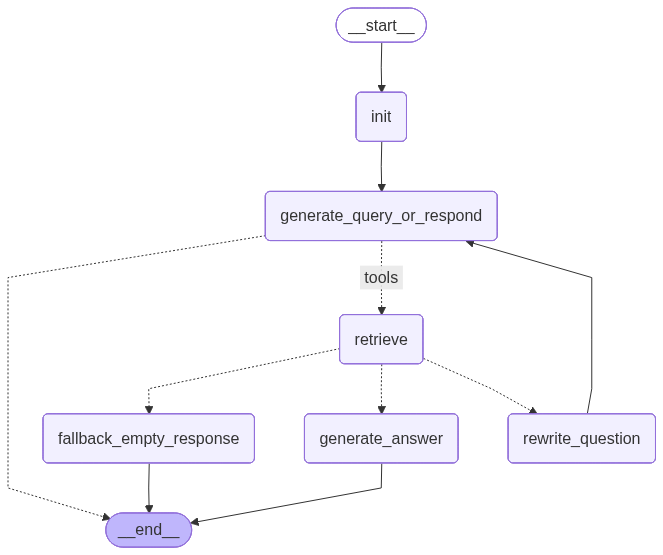

In [17]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
for chunk in graph.stream(
  {
    "messages": [
      {
        "role": "user",
        "content": "Analyze a transaction involving an NGN transfer from Sydney at late night using a new mobile device on a datacenter VPN.",
      }
    ]
  }
):
  for node, update in chunk.items():
    print("Update from node", node)
    update["messages"][-1].pretty_print()
    print("\n\n")

Update from node init
================================ Human Message =================================

Analyze a transaction involving an NGN transfer from Sydney at late night using a new mobile device on a datacenter VPN.



Update from node generate_query_or_respond
================================== Ai Message ==================================

[{'type': 'text', 'text': "I'll analyze this suspicious transaction pattern by querying our fraud database for similar cases."}, {'type': 'tool_use', 'name': 'retrieve_fraud_cases', 'input': {'query': 'NGN transfer Sydney late night new mobile device datacenter VPN'}, 'id': 'tooluse_HJh2akvgGyTxMIYMXrERnO'}, {'type': 'tool_use', 'name': 'retrieve_fraud_cases', 'input': {'query': 'international money transfer late night new device VPN anomaly'}, 'id': 'tooluse_RsOhc8JT2Zlw7lCwrWkJaA'}, {'type': 'tool_use', 'name': 'retrieve_fraud_cases', 'input': {'query': 'SIM swapping new device datacenter VPN transaction fraud'}, 'id': 'tooluse_uKVJCsP4E